In [152]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lstsq

## Problem 1: vector norms and convexity

Recall that a function $\|\cdot\|:\mathbb{R}^n\rightarrow\mathbb{R}$ is a vector norm if it satisfies the following three properties
- $\|x\|\geq 0$ and $\|x\|=0$ only when $x=0$,
- $\|\alpha x\| = |\alpha| \|x\|$ for all vectors $x$, and scalars $\alpha$
- $\|x+y\| \leq \|x\| + \|y\|$

**Part 1:** Show that every vector norm is a convex function.

Fix $n\in \mathbb{R}^n$ and let $\|\cdot\|:\mathbb{R}^n\rightarrow\mathbb{R}$ be a vector norm. It is easy to see that $\mathbb{R}^n$ is convex, so $\|\cdot\|$ has convex domain. Now, fix $x,y\in \mathbb{R}^n$ and $\theta\in [0,1]$. Observe that for all such choices of $\theta$, $|\theta|=\theta$ and $|(1-\theta)| = |(1-\theta)|$

Then $\|\theta x +(1-\theta)y\|\leq \|\theta x \| + \|(1-\theta)y\| = |\theta|\|x\|+|(1-\theta)|\|y\| = \theta\|x\|+(1-\theta)\|y\|$, as needed.

**Part 2:** Show that the unit ball $B=\left\{x\in\mathbb{R}^n \quad \mbox{such that} \quad \|x\|\leq 1\right\}$ is a convex set.

Fix $x,y\in B$. See that $\max\{\|x\|,\|y\|\}\leq 1$. Now, let $\theta\in [0,1]$ be arbitrary. From part 1, we know that $\|\theta x +(1-\theta)y\|\leq = \theta\|x\|+(1-\theta)\|y\|$. Then $\|\theta x +(1-\theta)y\|\leq \theta \cdot 1+(1-\theta)\cdot 1 = 1$. Thus $\theta x +(1-\theta)y\in B$, as needed.

## Problem 2: gradient descent

The **Rosenbrock's banana** function is defined as

$$
f(x,y)=(x−1)^2+10(y−x^2)^2
$$

In [2]:
# Rosenbrock's banana function
def ros(x,y):
    
    return (x-1)**2+10*(y-x**2)**2
    

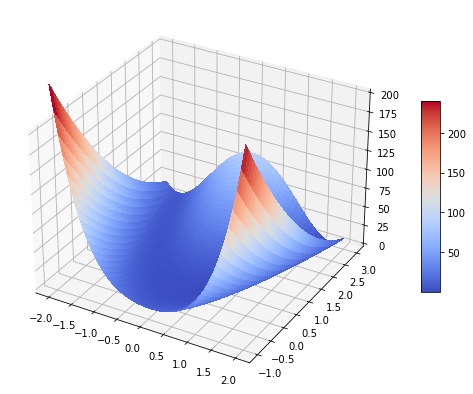

In [3]:
# run this cell to visualize the Rosenbrock function
from matplotlib import cm

# initialize figure 
figRos = plt.figure(figsize=(12, 7))
axRos = figRos.gca(projection='3d')

# evaluate function
x = np.linspace(-2, 2, 1000) 
y = np.linspace(-1, 3, 1000)
X, Y = np.meshgrid(x, y)
Z = ros(X,Y)

# Plot the surface
surf = axRos.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
axRos.set_zlim(0, 200)
figRos.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

The global minimum value of the Rosenbrock function is zero. 
That minimum is reached at the point (1,1).
This minimum is inside a long, narrow, banana shaped flat valley.
To find the valley is trivial.
To converge to the global minimum, however, is difficult

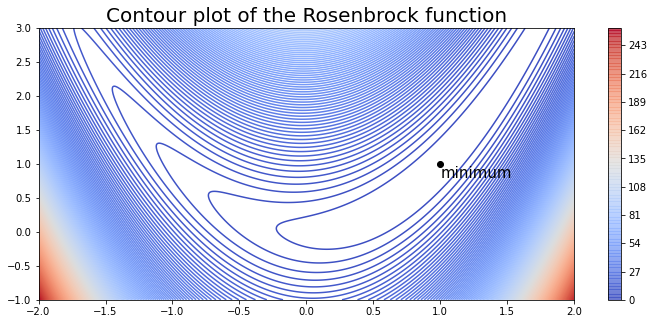

In [4]:
# run this cell to plot the contours of the Rosenbrock function
plt.figure(figsize=(12,5))
plt.contour(X,Y,Z,200, cmap=cm.coolwarm)
plt.plot(1,1,'ko')
plt.annotate('minimum', xy = (1,1),xytext=(1,1-0.2), fontsize=15)
plt.colorbar()
plt.title('Contour plot of the Rosenbrock function', fontsize=20)
plt.show()

**Part 1:** Find the gradient $\nabla f(x,y)$ 

In [16]:
# gradient of the Rosenbrock's banana function
def grad_ros(x,y):
    
    x_partial = 2*x-2-40*x*y+40*x*x*x
    y_partial = 20*(y-x**2)
    
    return np.array([x_partial,y_partial])

**Part 2:** Starting at the point (x,y)=(−1.25,2.75), how many iterations (epochs) does Gradient Descent need to find the minimum?

array([0.98884545, 0.9773643 ])

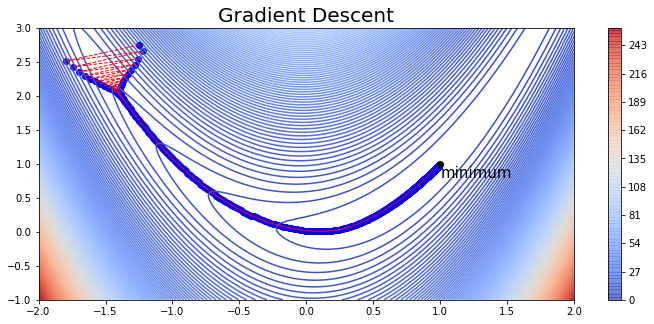

In [19]:
# set the learning rate and number of epochs, and run this cell.

##########################################
##########################################
# set learning rate
s = 0.01

# set number of epochs
epochs = 1000
##########################################
##########################################


# contour plot of the Rosenbrock's banana function
plt.figure(figsize=(12,5))
plt.contour(X,Y,Z,cmap=cm.coolwarm, levels=250)
plt.plot(1,1,'ko')
plt.annotate('minimum', xy = (1,1),xytext=(1,1-0.2), fontsize=15)
plt.colorbar()
plt.title('Gradient Descent',fontsize = 20)



# initial point 
x = np.array([-1.25,2.75]) 
plt.plot(x[0],x[1],'bo')


# plot gradient descent progress
for epoch in range(epochs): 
    new_x = x-s*grad_ros(x[0],x[1])
    plt.scatter(new_x[0],new_x[1],c='blue')
    plt.plot([x[0],new_x[0]],[x[1],new_x[1]], 'r--', linewidth=1)
    x = new_x
    
x

**Part 3:** Note that the Rosenbrock banana function can be written as 

$$
f(x,y) = \|F(x,y) \|_2^2 \qquad \mbox{where} \qquad 
F(x,y) =
\begin{bmatrix} x-1 \\ 10(y-x^2) \end{bmatrix}
$$

Starting from the point (x,y)=(−1.25,2.75), use the Levenberg-Marquardt method  to find the minimum of $f(x,y)$

NOTE: I think that the given function $F(x,y)$ is off- instead of $10$, it should be $\sqrt{10}$

In [21]:
def F(x,y):
    return np.array([x-1,np.sqrt(10)*(y-x**2)])

In [20]:
def fun(x,y):
    return np.linalg.norm(F(x,y))**2

array([1., 1.])

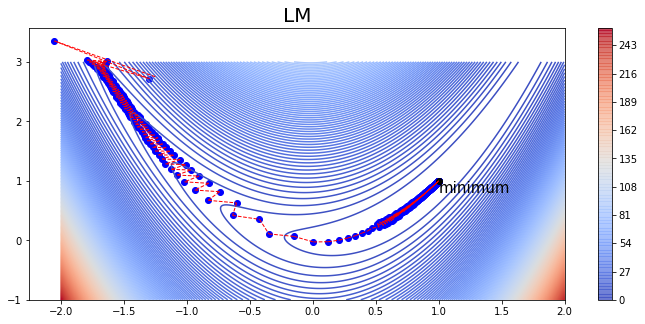

In [32]:
x = np.array([-1.25,2.75]) #Gauss - Newton doesn't work here

# number of iterations
max_it = 10000

# initial lambda
lam=0.5

# starting ||f(x)||
e = np.linalg.norm(fun(x[0],x[1]))
error = [e]

n_parameters = len(x)

# contour plot of the Rosenbrock's banana function
plt.figure(figsize=(12,5))
plt.contour(X,Y,Z,cmap=cm.coolwarm, levels=250)
plt.plot(1,1,'ko')
plt.annotate('minimum', xy = (1,1),xytext=(1,1-0.2), fontsize=15)
plt.colorbar()
plt.title('LM',fontsize = 20)

for i in range(max_it):
    # function f(x)
    f = fun(x[0],x[1])
    # Jacobian Df(x)
    D = grad_ros(x[0],x[1])
    # L-M iteration
    new_x = x - np.linalg.inv(D.T.dot(D) + lam*np.eye(n_parameters)).dot(D.T.dot(f))
    
    # check if ||f(x)|| has decreased
    new_e = np.linalg.norm(fun(new_x[0],new_x[1]))
    if new_e < e:
        plt.scatter(new_x[0],new_x[1],c='blue')
        plt.plot([x[0],new_x[0]],[x[1],new_x[1]], 'r--', linewidth=1)
        x = new_x
        lam = 0.8*lam
        e = new_e
        error.append(e)
    else:
        lam=1.2*lam
        
x

## Problem 3: Linear and nonlinear least squares problems

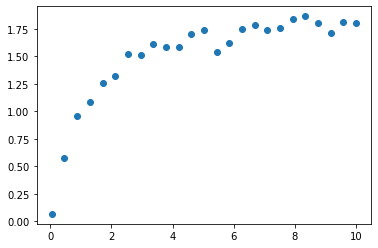

In [170]:
# generate some synthetic data 
m = 25
t = np.linspace(0.05,10,m)
y = t/(0.5*t+0.5) + 0.05*np.random.randn(m)
plt.scatter(t,y)

**Part 1:** Solve a nonlinear least squares problem to fit a function of the form 
$$
y(t) = \frac{t}{at+b}
$$
to the data. 
Then plot the data and the fitted function.

In [171]:
# function f(x)
def fun(x,t,y):
    return t/(x[1]+x[0]*t)-y

In [172]:
# jacobian of above function for changing a and b
def Dfun(x,t,y):
    m= len(t)
    col_1=-t**2/(x[1]+x[0]*t)**2
    col_2=-t/(x[1]+x[0]*t)**2
    return np.hstack((col_1.reshape(m,1),col_2.reshape(m,1)))

In [173]:
# Gauss-Newton
x = np.array([0.6,0.4])
it = 1000
error = []
for i in range(it):
    f = fun(x,t,y)
    Der = Dfun(x,t,y)
    x = x - np.linalg.inv((Der.T.dot(Der))).dot(Der.T.dot(f))
    error.append(np.linalg.norm(f))

x

array([0.49825426, 0.5073368 ])

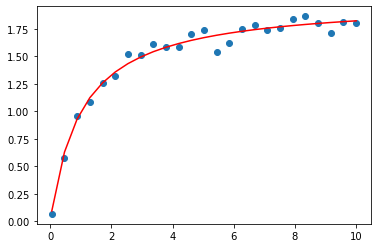

In [174]:
# let's try plotting?
y_pred = t/(x[1]+x[0]*t)

plt.scatter(t,y)
plt.plot(t,y_pred, color = 'red')

**Part 2:** Show that finding a best fit of the form
$$
y(t) = \frac{t}{at+b}
$$
can be transformed into a linear fitting problem by rewritting the equation.

Taking the reciprocal of the above equation, we see that

$$ 1/y(t) = (at+b)/t = a+b(1/t) $$


**Part 3:** Solve a linear least squares problem to fit a function of the form 
$$
y(t) = \frac{t}{at+b}
$$
to the data. 
Then plot the data and the fitted function.

In [175]:
y_rep = 1/y
t_rep = 1/t
m = len(t)

A = np.ones((m,2))
A[:,1] = t_rep

coeffs = lstsq(A,y_rep)[0]

coeffs

array([0.4279756 , 0.72144665])

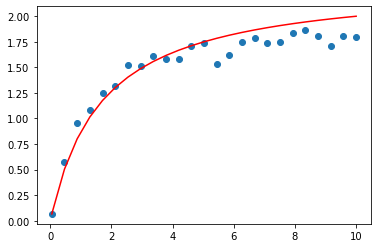

In [177]:
y_pred = t/(coeffs[1]+coeffs[0]*t)

plt.scatter(t,y)
plt.plot(t,y_pred, color = 'red')

## Problem 4

Consider the following data points

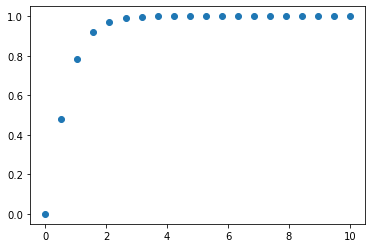

In [147]:
t = np.linspace(0,10,20)
y = np.tanh(t)
plt.scatter(t,y)

**Part 1:** Fit the data to a cubic polynomial, and plot the data together with the polynomial fit.

In [153]:
m = len(t)
A = np.ones((m,4))
A[:,1] = t
A[:,2] = t**2
A[:,3] = t**3

coeffs = lstsq(A,y)[0]

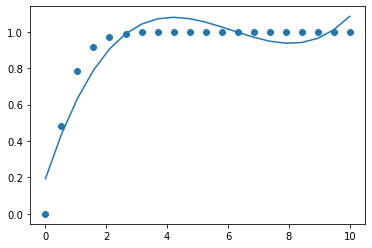

In [156]:
plt.scatter(t,y)
plt.plot(t,A.dot(coeffs.T))

**Part 2:** Fit the data to the function $c_1+c_2z + c_3z^2 + c_4z^3$, where $z=t^2/(1+t^2)$.

Plot the data together with the fit. What feature of $z$ makes this fit much better than the original cubic.

In [161]:
z = t**2/(1+t**2)

B = np.zeros((m,4))
for i in range(4):
    B[:,i] = z**i
    
coeffs = lstsq(B,y)[0]

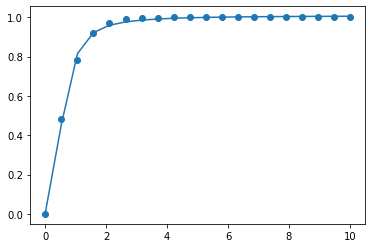

In [162]:
plt.scatter(t,y)
plt.plot(t,B.dot(coeffs.T))

What makes this fit so much better? I don't really know, actually. If I had to guess, I would assume it has something to do with the series expansion of hyperbolic tangent.